# Analisi Esplorativa del Dataset MeQSum

**Progetto NLP — Clinical Summarization: NLP Tradizionale vs LLM**  
Corso: Natural Language Processing (Laurea Magistrale)  
Docenti: Prof.ssa G. Tortora, Prof.ssa L. Caruccio

---

Questo notebook esplora il dataset **MeQSum** (Medical Question Summarization) rilasciato dal NIH.  
L'obiettivo è caratterizzare la distribuzione dei dati prima di avviare le pipeline di processing.

**Struttura del dataset:**
- `File`: identificatore della sorgente originale
- `CHQ` *(Consumer Health Question)*: domanda grezza inviata dal paziente
- `Summary`: sintesi clinica formalizzata dagli esperti NIH (Ground Truth)

## 1. Setup e Caricamento

In [15]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

# Stile grafici
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

DATA_PATH = '../data/MeQSum_ACL2019_BenAbacha_Demner-Fushman.xlsx'

df = pd.read_excel(DATA_PATH)
print(f'Dataset caricato: {df.shape[0]} esempi, {df.shape[1]} colonne')
print(f'Colonne: {list(df.columns)}')

Dataset caricato: 1000 esempi, 3 colonne
Colonne: ['File', 'CHQ', 'Summary']


## 2. Panoramica Generale

In [17]:
print('=== Valori nulli ===')
print(df.isnull().sum())

print('\n=== Duplicati ===')
print(f'CHQ duplicate:     {df["CHQ"].duplicated().sum()}')
print(f'Summary duplicate: {df["Summary"].duplicated().sum()}')

=== Valori nulli ===
File       0
CHQ        0
Summary    0
dtype: int64

=== Duplicati ===
CHQ duplicate:     0
Summary duplicate: 6


In [18]:
# Mostra 5 esempi casuali
pd.set_option('display.max_colwidth', 120)
df[['CHQ', 'Summary']].sample(5, random_state=42)

,CHQ,Summary
521,SUBJECT: new treatment for lipoma of forearm\nMESSAGE: I have had two surgeries on my right forearm. The last was 2...,What are the latest treatments for recurrent lipoma of the arm?
737,Beckwith-Wieddeman Syndrome. I would like to request further knowledge on this specific disorder.,Where can I find information about Beckwith-Wieddeman Syndrome?
740,"SUBJECT: MedlinePlus Service Request\nMESSAGE: if A PERSON HAS BEEN USING MORPHINE FOR YEARS (10)FOR PAIN RELIEF,AND...",Are the long-term effects of morphine reversible?
660,"SUBJECT: How is ""elderly"" defined in cautionarys regarding dosage.\nMESSAGE: Lower dosages of various medications ar...","How is ""elderly"" defined in drug precautions regarding dosage?"
411,Im suffering from Beta Thalassemia Major from birth. I have been transfusing every 22 days. Now i heard about a tabl...,Is mylostat 500 a treatment for Beta Thalassemia Major?


## 3. Statistiche sulle Lunghezze dei Testi

In [19]:
# Feature di lunghezza
df['chq_words']  = df['CHQ'].str.split().str.len()
df['chq_chars']  = df['CHQ'].str.len()
df['sum_words']  = df['Summary'].str.split().str.len()
df['sum_chars']  = df['Summary'].str.len()
df['compression_ratio'] = (df['chq_words'] / df['sum_words']).round(2)

stats = pd.DataFrame({
    'CHQ (parole)':       df['chq_words'],
    'Summary (parole)':   df['sum_words'],
    'Compression Ratio':  df['compression_ratio'],
}).describe().round(2)

print(stats.to_string())

       CHQ (parole)  Summary (parole)  Compression Ratio
count       1000.00           1000.00            1000.00
mean          60.78             10.04               6.63
std           46.62              3.65               5.60
min            5.00              3.00               1.00
25%           30.00              7.00               3.18
50%           47.00              9.00               4.94
75%           75.25             12.00               8.29
max          378.00             26.00              58.40


**Osservazioni chiave:**
- I CHQ hanno in media **~61 parole** (range: 5–378), con alta varianza → testi molto eterogenei
- I Summary hanno in media **~10 parole** (range: 3–26) → sintesi molto compatte
- Il **compression ratio medio è ~6.6×**: il modello deve ridurre drasticamente il testo

## 4. Distribuzione delle Lunghezze

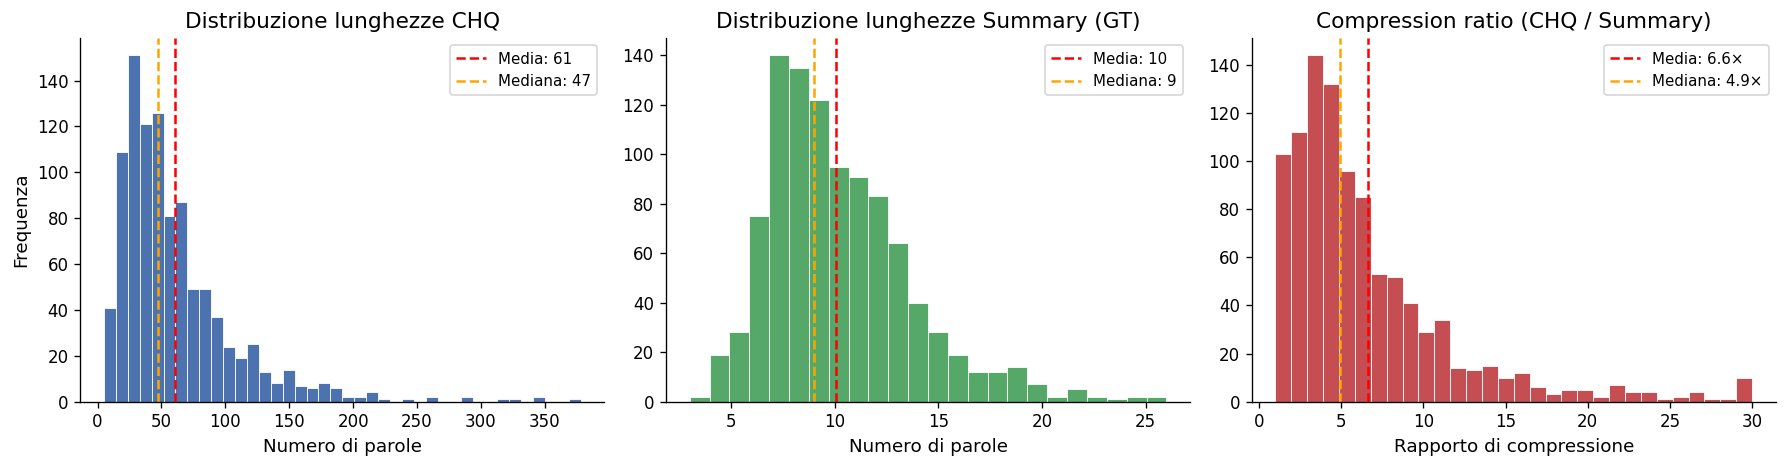

Figura salvata in results/fig_length_distributions.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# CHQ
axes[0].hist(df['chq_words'], bins=40, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['chq_words'].mean(),  color='red',    linestyle='--', linewidth=1.5, label=f'Media: {df["chq_words"].mean():.0f}')
axes[0].axvline(df['chq_words'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df["chq_words"].median():.0f}')
axes[0].set_title('Distribuzione lunghezze CHQ')
axes[0].set_xlabel('Numero di parole')
axes[0].set_ylabel('Frequenza')
axes[0].legend(fontsize=9)

# Summary
axes[1].hist(df['sum_words'], bins=24, color='#55A868', edgecolor='white', linewidth=0.5)
axes[1].axvline(df['sum_words'].mean(),  color='red',    linestyle='--', linewidth=1.5, label=f'Media: {df["sum_words"].mean():.0f}')
axes[1].axvline(df['sum_words'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df["sum_words"].median():.0f}')
axes[1].set_title('Distribuzione lunghezze Summary (GT)')
axes[1].set_xlabel('Numero di parole')
axes[1].legend(fontsize=9)

# Compression ratio
axes[2].hist(df['compression_ratio'].clip(upper=30), bins=30, color='#C44E52', edgecolor='white', linewidth=0.5)
axes[2].axvline(df['compression_ratio'].mean(),  color='red',    linestyle='--', linewidth=1.5, label=f'Media: {df["compression_ratio"].mean():.1f}×')
axes[2].axvline(df['compression_ratio'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df["compression_ratio"].median():.1f}×')
axes[2].set_title('Compression ratio (CHQ / Summary)')
axes[2].set_xlabel('Rapporto di compressione')
axes[2].legend(fontsize=9)

plt.tight_layout()

# Questa riga controlla se la cartella esiste; se non esiste, la crea!
os.makedirs('results', exist_ok=True)

# Ora puoi salvare senza paura di errori
plt.savefig('results/fig_length_distributions.png', bbox_inches='tight')
plt.show()
print('Figura salvata in results/fig_length_distributions.png')

## 5. Scatter: Lunghezza CHQ vs Summary

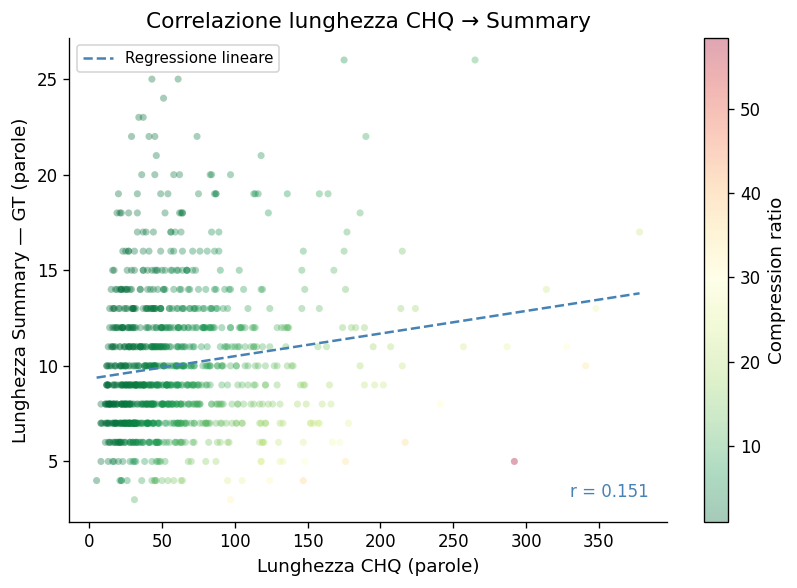

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    df['chq_words'], df['sum_words'],
    alpha=0.35, s=18, c=df['compression_ratio'],
    cmap='RdYlGn_r', edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Compression ratio')

# Linea di regressione
m, b = np.polyfit(df['chq_words'], df['sum_words'], 1)
x_line = np.linspace(df['chq_words'].min(), df['chq_words'].max(), 100)
ax.plot(x_line, m * x_line + b, color='steelblue', linewidth=1.5, linestyle='--', label='Regressione lineare')

ax.set_xlabel('Lunghezza CHQ (parole)')
ax.set_ylabel('Lunghezza Summary — GT (parole)')
ax.set_title('Correlazione lunghezza CHQ → Summary')
ax.legend(fontsize=9)

corr = df['chq_words'].corr(df['sum_words'])
ax.text(0.97, 0.05, f'r = {corr:.3f}', transform=ax.transAxes,
        ha='right', fontsize=10, color='steelblue')

plt.tight_layout()
plt.savefig('results/fig_scatter_chq_vs_summary.png', bbox_inches='tight')
plt.show()

## 6. Casi Estremi: CHQ molto lunghi e molto corti

In [22]:
print('=== TOP 3 CHQ più lunghi ===')
long_df = df.nlargest(3, 'chq_words')[['chq_words', 'CHQ', 'Summary']]
for _, row in long_df.iterrows():
    print(f'\n[{row["chq_words"]} parole]')
    print(f'  CHQ:     {row["CHQ"][:200]}...')
    print(f'  Summary: {row["Summary"]}')

=== TOP 3 CHQ più lunghi ===

[378 parole]
  CHQ:     Hi All,
I am from India and really worried.
I have a 6 months old baby girl. I have read the article on Lactose intolerance. She is unable to digest any formula milk or any milk products. When she was...
  Summary: Where can I get help for my 6 months old baby girl with Lactose intolerance in India?

[348 parole]
  CHQ:     ClinicalTrials.gov - Question - general information.
 Hello, 
My name is [NAME],I am 30 years old and I am from [LOCATION]. I met my friend [NAME] on a chat room. [NAME] is 25 years old and he current...
  Summary: Where can I get information about treatment for T-6 and T-7 fracture paraplegia?

[341 parole]
  CHQ:     Hello.
I am writing this mail from [LOCATION]. This in regards with seeking help for
Ulceratice colitis.
My mother is suffering from this diseases from last 3 Years. Her treatment
is going with [LOCAT...
  Summary: Where can I get advice and help for ulceratice colitis?


In [23]:
print('=== TOP 3 CHQ più corti ===')
short_df = df.nsmallest(3, 'chq_words')[['chq_words', 'CHQ', 'Summary']]
for _, row in short_df.iterrows():
    print(f'\n[{row["chq_words"]} parole]')
    print(f'  CHQ:     {row["CHQ"]}')
    print(f'  Summary: {row["Summary"]}')

=== TOP 3 CHQ più corti ===

[5 parole]
  CHQ:     bile.
 because reason vomit bile?
  Summary: What causes vomiting bile?

[8 parole]
  CHQ:     cinca sindrome. where the treatment of cinca sindrome.
  Summary: What are the tratments for cinca syndrome?

[8 parole]
  CHQ:     are jumping genes[transposons] associated with lynch syndrome? [NAME]
  Summary: Are jumping genes [transposons] associated with Lynch syndrome?


## 7. Fasce di Complessità

            n_esempi  media_chq_words  media_sum_words  media_ratio
chq_bucket                                                         
≤20              101            15.30             8.86         1.86
21–50            434            34.82             9.73         4.01
51–100           317            69.77            10.59         7.43
101–200          131           133.24            10.41        14.61
>200              17           267.35            12.00        25.27


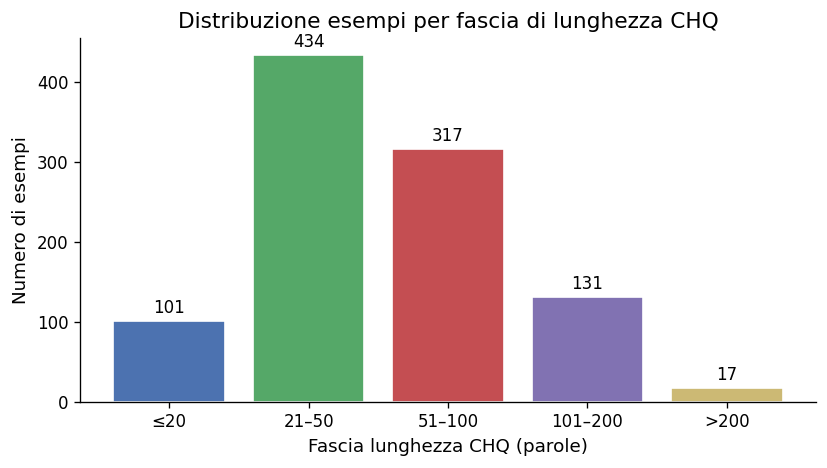

In [24]:
# Segmentiamo i CHQ in fasce di lunghezza
bins   = [0, 20, 50, 100, 200, float('inf')]
labels = ['≤20', '21–50', '51–100', '101–200', '>200']

df['chq_bucket'] = pd.cut(df['chq_words'], bins=bins, labels=labels)

bucket_stats = df.groupby('chq_bucket', observed=True).agg(
    n_esempi        = ('CHQ', 'count'),
    media_chq_words = ('chq_words', 'mean'),
    media_sum_words = ('sum_words', 'mean'),
    media_ratio     = ('compression_ratio', 'mean'),
).round(2)

print(bucket_stats.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
bars = ax.bar(bucket_stats.index, bucket_stats['n_esempi'], color=colors, edgecolor='white')

for bar, val in zip(bars, bucket_stats['n_esempi']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Fascia lunghezza CHQ (parole)')
ax.set_ylabel('Numero di esempi')
ax.set_title('Distribuzione esempi per fascia di lunghezza CHQ')
plt.tight_layout()
plt.savefig('results/fig_chq_buckets.png', bbox_inches='tight')
plt.show()

## 8. Riepilogo Finale

In [25]:
print('╔══════════════════════════════════════════════════╗')
print('║        RIEPILOGO DATASET MeQSum                  ║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  Totale esempi          : {len(df):>6}                  ║')
print(f'║  Valori nulli           : {df[["CHQ","Summary"]].isnull().sum().sum():>6}                  ║')
print(f'║  CHQ — media parole     : {df["chq_words"].mean():>6.1f}                  ║')
print(f'║  CHQ — max parole       : {df["chq_words"].max():>6}                  ║')
print(f'║  Summary — media parole : {df["sum_words"].mean():>6.1f}                  ║')
print(f'║  Compression ratio medio: {df["compression_ratio"].mean():>6.1f}×                 ║')
print('╚══════════════════════════════════════════════════╝')

print('\nImplicazioni per le pipeline:')
print('  • TextRank (Pipeline A): compression ratio alto → selezione aggressiva delle frasi')
print('  • LLM (Pipeline B): CHQ rumorosi e lunghi → prompt engineering cruciale')
print('  • max_new_tokens = 64–128 è sufficiente per replicare la lunghezza dei Summary GT')

╔══════════════════════════════════════════════════╗
║        RIEPILOGO DATASET MeQSum                  ║
╠══════════════════════════════════════════════════╣
║  Totale esempi          :   1000                  ║
║  Valori nulli           :      0                  ║
║  CHQ — media parole     :   60.8                  ║
║  CHQ — max parole       :    378                  ║
║  Summary — media parole :   10.0                  ║
║  Compression ratio medio:    6.6×                 ║
╚══════════════════════════════════════════════════╝

Implicazioni per le pipeline:
  • TextRank (Pipeline A): compression ratio alto → selezione aggressiva delle frasi
  • LLM (Pipeline B): CHQ rumorosi e lunghi → prompt engineering cruciale
  • max_new_tokens = 64–128 è sufficiente per replicare la lunghezza dei Summary GT


In [26]:
# Salva dataset con feature di lunghezza per usi successivi
import os
os.makedirs('results', exist_ok=True)
df.to_csv('results/dataset_with_features.csv', index=False)
print('Dataset con feature salvato in results/dataset_with_features.csv')

Dataset con feature salvato in results/dataset_with_features.csv
